# Figure 4 — graded depth profiles

Compare the book-ended graded film to slab DFT and free-tensor models at one
probe energy, then export the unrolled manuscript figure (``FIG4``).

The DFT-slab curves come from the multi-energy refloxide ``Objective`` pickle
via ``utils.refloxide_view`` (same drop-in as ``fig_3_orientation.ipynb``).
Free-tensor remains the pyref ``GlobalObjective`` pickle. Notebook filename is
still ``fig_5_graded.ipynb`` for historical reasons; the manuscript figure is
**FIG4**.


## 1. Load data


In [46]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import erf

from utils import (
    models_root,
    objectives_retarget_energies,
    read_fit,
    read_xrr,
)
from utils.graded_objective import extract_graded_fit_context
from utils.helpers.fitting_helper import rxr
from utils.helpers.plotting_helper import set_plotting_defaults
from utils.models import configure_refloxide_fitting
from utils.refloxide_view import load_refloxide_fit, objective_view_at

configure_refloxide_fitting()
set_plotting_defaults()

ENERGY = 283.7
REFLOXIDE_FIT_PATH = models_root / "xrr/znpc/refloxide/refit-refloxide.pkl"

data = read_xrr("reflectivity_data", material="znpc", source="hub")
graded_fit = read_fit("graded/graded_fit.pkl", material="znpc", source="local")
free_fit = read_fit("free/free_en_offset_init_2.pkl", material="znpc", source="local")
graded_obj = objectives_retarget_energies(graded_fit, [ENERGY], data=data)[ENERGY]


def pick_energy_objective(global_obj, energy):
    """Return the single-energy objective nearest ``energy`` from a GlobalObjective."""
    energies = np.array([o.model.energy for o in global_obj.objectives], dtype=float)
    idx = int(np.argmin(np.abs(energies - energy)))
    return global_obj.objectives[idx]


if not REFLOXIDE_FIT_PATH.exists():
    raise FileNotFoundError(
        f"missing {REFLOXIDE_FIT_PATH} -- run the save cell in "
        "real_data_fit.ipynb (or refloxide/examples/real_data_repl.py) first"
    )

refloxide_objective = load_refloxide_fit(REFLOXIDE_FIT_PATH)
# Hub read_xrr s/p labels are opposite the refloxide fit dataset; swap so
# rxr(..., "s"|"p") lines up with dataset.s / dataset.p.
refloxide_obj = objective_view_at(refloxide_objective, ENERGY, swap_pol=True)
dft_obj = refloxide_obj
free_obj = pick_energy_objective(free_fit, ENERGY)
dataset = data[str(ENERGY)]
print(
    f"refloxide DFT slab at {ENERGY} eV: "
    f"{len(refloxide_obj.varying_parameters())} varying"
)


refloxide DFT slab at 283.7 eV: 101 varying


## 2. Best-fit parameters

Graded book-ended film at the probe energy (the red curve in FIG4). Angles
are stored in radians on the objective; the table also reports degrees.


In [47]:
import pandas as pd
from IPython.display import display
from uncertainties import ufloat
import numpy as np

_ANGLE_PARAMS = ("alpha_bulk", "alpha_si", "alpha_vac")

def format_ufloat_degree(uval):
    if uval.nominal_value is np.nan:
        return "-"
    # Cast to degrees
    uval_deg = ufloat(np.degrees(uval.nominal_value), np.degrees(uval.std_dev))
    return f"{uval_deg:.2uP}"  # 2 sig figs, pretty-print

def format_ufloat(uval):
    if uval.nominal_value is np.nan:
        return "-"
    return f"{uval:.2uP}"

def _param_rows(objective):
    rows = []
    for p in objective.varying_parameters():
        name = str(p.name)
        value = float(p.value)
        stderr = float(p.stderr) if getattr(p, "stderr", None) is not None else float("nan")
        val_ufloat = ufloat(value, stderr) if np.isfinite(stderr) else ufloat(value, 0)

        # If it's an angle, store degree value also in 'value (val±err)', otherwise store as is.
        if name in _ANGLE_PARAMS:
            # Convert to degrees for main value column.
            val_deg = ufloat(np.degrees(val_ufloat.nominal_value), np.degrees(val_ufloat.std_dev))
            row = {
                "parameter": name,
                "value (val±err)": f"{val_deg:.2uP}",
                "value_deg (val±err)": f"{val_deg:.2uP}",
            }
        else:
            row = {
                "parameter": name,
                "value (val±err)": format_ufloat(val_ufloat),
                "value_deg (val±err)": "-",
            }
        rows.append(row)
    return rows

graded_params = pd.DataFrame(_param_rows(graded_obj))
_film = extract_graded_fit_context(graded_obj).film
fixed_film = pd.DataFrame(
    [
        {
            "parameter": "density_bulk",
            "value (val±err)": format_ufloat(ufloat(float(_film.density_bulk.value), 0)),
            "note": "fixed (not varying)",
        },
        {
            "parameter": "energy_offset",
            "value (val±err)": format_ufloat(ufloat(float(_film.energy_offset.value), 0)),
            "note": "fixed (not varying)",
        },
    ]
)

print(f"Graded best fit @ {ENERGY} eV  ({len(graded_params)} varying)")
display(
    graded_params.style.format(
        {
            "value (val±err)": lambda x: x,
            "value_deg (val±err)": lambda x: x,
        },
        na_rep="-",
    )
)
print("Fixed film parameters carried with the graded model:")
display(fixed_film.style.format({"value (val±err)": lambda x: x}, na_rep="-"))


Graded best fit @ 283.7 eV  (13 varying)


/Users/hduva/projects/refl-analysis/.venv/lib/python3.12/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


,parameter,value (val±err),value_deg (val±err)
0,scale_s,1.453±0.022,-
1,scale_p,1.489±0.013,-
2,theta_offset_s,0.345±0.020,-
3,theta_offset_p,0.279±0.041,-
4,total_thick,188.75±0.27,-
5,surface_roughness,8.37±0.19,-
6,density_si,0.872±0.063,-
7,density_vac,1.979±0.062,-
8,tau_si,16.90±0.65,-
9,tau_vac,25.0±1.9,-


Fixed film parameters carried with the graded model:


,parameter,value (val±err),note
0,density_bulk,1.6385167795334732±0,fixed (not varying)
1,energy_offset,0.003493781726748201±0,fixed (not varying)


## 3. Helpers


In [48]:
def nevot_croce_density(film, *, n_points: int = 2000, n_sigma: int = 5):
    """Convolve the book-ended density with the surface (vacuum) Névot-Croce term.

    The Névot-Croce interface is an error function, so its real-space density is
    the analytic profile convolved with a Gaussian of standard deviation equal to
    ``film.surface_roughness``. Vacuum (zero density) bounds the surface side and
    the film-edge density bounds the substrate side so the convolution sees the
    physical boundary on each end.

    Parameters
    ----------
    film
        Book-ended film component.
    n_points
        Samples across the film thickness.
    n_sigma
        Padding width in units of the surface roughness.

    Returns
    -------
    depth, rho_sharp, rho_rough
        Depth (angstrom) and the analytic and roughness-smeared densities
        (g/cm^3) on ``[0, total_thick]``.
    """
    total = float(film.total_thick.value)
    sigma = float(film.surface_roughness.value)
    depth = np.linspace(0.0, total, n_points)
    rho_sharp = np.asarray(film.local_density(depth), dtype=float)
    if sigma <= 0.0:
        return depth, rho_sharp, rho_sharp.copy()

    dz = depth[1] - depth[0]
    pad = int(np.ceil(n_sigma * sigma / dz))
    z_ext = np.concatenate(
        [depth[0] + dz * np.arange(-pad, 0), depth, depth[-1] + dz * np.arange(1, pad + 1)]
    )
    rho_ext = np.empty_like(z_ext)
    below, above = z_ext < 0.0, z_ext > total
    inside = ~(below | above)
    rho_ext[below] = 0.0
    rho_ext[inside] = np.asarray(film.local_density(z_ext[inside]), dtype=float)
    rho_ext[above] = float(film.local_density(total))

    kernel = np.exp(-0.5 * (dz * np.arange(-pad, pad + 1) / sigma) ** 2)
    kernel /= kernel.sum()
    rho_rough = np.convolve(rho_ext, kernel, mode="same")[pad : pad + n_points]
    return depth, rho_sharp, rho_rough


def slab_film_profiles(model, idx=(1, 2, 3), n=600):
    """Erf-smoothed orientation (deg) and density for the 3-slab ZnPc film.

    Measured from the vacuum interface so the depth axis matches the graded film.
    Assumes vacuum|surf|bulk|inter|SiO2|Si and that component[i].rough sets the
    interface above slab i.
    """
    s = [model.structure[i] for i in idx]
    t = np.array([float(c.thick.value) for c in s])
    a = np.array([float(c.sld.rotation.value) for c in s])
    rho = np.array([float(c.sld.density.value) for c in s])
    r1 = max(float(s[1].rough.value), 1e-6)
    r2 = max(float(s[2].rough.value), 1e-6)
    total = float(t.sum())
    z = np.linspace(0.0, total, n)
    z1, z2 = t[0], t[0] + t[1]
    step1 = 0.5 * (1.0 + erf((z - z1) / (np.sqrt(2.0) * r1)))
    step2 = 0.5 * (1.0 + erf((z - z2) / (np.sqrt(2.0) * r2)))

    def blend(v):
        return v[0] + (v[1] - v[0]) * step1 + (v[2] - v[1]) * step2

    return z, np.degrees(blend(a)), blend(rho)


QMIN = 0.1


def log_residual(y, y_model, y_err):
    """Normalized log difference ``(ln y - ln y_model) / (y_err / y)``.

    Matches the fractional-error log residual used in the edge-fit helpers
    (``wm = y_err / y``). Prefer this over ``(y - y_model) / y_err`` on
    log-scaled reflectivity, where absolute residuals overweight low-R points.
    """
    y = np.asarray(y, dtype=float)
    y_model = np.asarray(y_model, dtype=float)
    y_err = np.asarray(y_err, dtype=float)
    return (np.log(np.clip(y, 1e-30, None)) - np.log(np.clip(y_model, 1e-30, None))) / (
        y_err / y
    )


def rms_residual(model, pol=("s", "p")):
    """RMS normalized log residual over the plotted q window."""
    chis = []
    for p in pol:
        d = getattr(dataset, p)
        m = d.x >= QMIN
        chis.append(log_residual(d.y[m], rxr(d.x[m], model, p), d.y_err[m]))
    return float(np.sqrt(np.mean(np.concatenate(chis) ** 2)))


## 4. Profiles and painters


In [54]:
from matplotlib.lines import Line2D

_TAB20 = plt.colormaps["tab20"]
C_S, C_P = _TAB20(2), _TAB20(3)
C_GRADED = _TAB20(2)
C_DFT = "0.15"
C_FREE = "0.42"
MODELS = [
    {"name": "Graded", "obj": graded_obj, "color": C_GRADED, "ls": "-", "lw": 1.1, "z": 5},
    {"name": "DFT slab", "obj": dft_obj, "color": C_DFT, "ls": "--", "lw": 1.0, "z": 4},
    {"name": "Free slab", "obj": free_obj, "color": C_FREE, "ls": "-", "lw": 1.0, "z": 4},
]

Q = np.linspace(QMIN, float(dataset.s.x.max()), 1500)
DATA_EVERY = 3
Z_LEFT = -6.0
R_YLIM = (1e-8, 1e-3)
GAMMA_YLIM = (20, 75)
RHO_YLIM = (0.5, 2.2)
CHI_YLIM = (-6.0, 6.0)
TAU_COLOR = "#0b7f8a"
TAU_LW = 0.85
TAU_LS = (0, (4, 3))

film = extract_graded_fit_context(graded_obj).film
TOTAL = float(film.total_thick.value)
TAU_VAC, TAU_SI = float(film.tau_vac.value), float(film.tau_si.value)
DEPTH_XLIM = (Z_LEFT, TOTAL)
Z_G, RHO_SHARP, RHO_ROUGH = nevot_croce_density(film)
ALPHA_G = np.degrees(np.asarray(film.orientation(Z_G), dtype=float))
Z_DFT, ALPHA_DFT, RHO_DFT = slab_film_profiles(dft_obj.model)
Z_FREE, ALPHA_FREE, RHO_FREE = slab_film_profiles(free_obj.model)
RMSE = {m["name"]: rms_residual(m["obj"].model) for m in MODELS}


def _subsample_xyerr(x, y, yerr, every):
    x_arr = np.asarray(x, dtype=float)
    y_arr = np.asarray(y, dtype=float)
    err_arr = np.asarray(yerr, dtype=float)
    if every <= 1:
        return x_arr, y_arr, err_arr
    idx = np.arange(0, len(x_arr), every, dtype=int)
    return x_arr[idx], y_arr[idx], err_arr[idx]


def highlight_interface(ax, *, halo=True, labels=True):
    """Vacuum and buried graded-interface markers (fig_2 diagnostic tau styling)."""
    for z_tau, txt, ha, dx in (
        (TAU_VAC, r"$\tau_\mathrm{vac}$", "left", 3),
        (TOTAL - TAU_SI, r"$\tau_\mathrm{Si}$", "right", -3),
    ):
        if halo:
            ax.axvline(
                z_tau,
                color="white",
                lw=TAU_LW + 1.1,
                solid_capstyle="butt",
                zorder=4,
            )
        ax.axvline(
            z_tau,
            color=TAU_COLOR,
            lw=TAU_LW,
            ls=TAU_LS,
            solid_capstyle="butt",
            zorder=5,
        )
        if labels:
            ax.annotate(
                txt,
                xy=(z_tau, 0.5),
                xycoords=("data", "axes fraction"),
                xytext=(dx, 0),
                textcoords="offset points",
                va="top",
                ha=ha,
                color=TAU_COLOR,
                fontsize=7,
            )


def draw_reflectivity(ax, legend_loc="lower left"):
    for pol, marker in (("s", "o"), ("p", "^")):
        d = getattr(dataset, pol)
        m = d.x >= QMIN
        xs, ys, es = _subsample_xyerr(d.x[m], d.y[m], d.y_err[m], DATA_EVERY)
        col = C_S if pol == "s" else C_P
        ax.errorbar(
            xs,
            ys,
            yerr=es,
            fmt=marker,
            lw=0,
            ms=2.8,
            elinewidth=0.45,
            capsize=1.2,
            capthick=0.45,
            color=col,
            ecolor=col,
            zorder=10,
        )
    for mdl in MODELS:
        for pol in ("s", "p"):
            ax.plot(
                Q,
                rxr(Q, mdl["obj"].model, pol),
                color=mdl["color"],
                ls=mdl["ls"],
                lw=mdl["lw"],
                zorder=mdl["z"],
                label=mdl["name"] if pol == "s" else None,
            )
    ax.set_yscale("log")
    ax.set_xlim(QMIN, Q.max())
    ax.set_ylim(*R_YLIM)
    ax.set_ylabel("Reflectivity (a.u.)")
    ax.minorticks_on()
    ax.legend(
        loc=legend_loc,
        fontsize=6.5,
        handlelength=1.2,
        handletextpad=0.4,
        borderpad=0.3,
        labelspacing=0.25,
        framealpha=0.9,
        edgecolor="0.75",
        fancybox=False,
    )


def draw_residual(ax):
    yl, yh = CHI_YLIM
    ax.axhline(
        0.0,
        color=plt.rcParams["axes.edgecolor"],
        lw=plt.rcParams["axes.linewidth"],
    )
    d = dataset.p
    m = d.x >= QMIN
    residual_order = [mdl for mdl in MODELS if mdl["name"] != "DFT slab"] + [
        mdl for mdl in MODELS if mdl["name"] == "DFT slab"
    ]
    for mdl in residual_order:
        chi = log_residual(d.y[m], rxr(d.x[m], mdl["obj"].model, "p"), d.y_err[m])
        ax.plot(
            d.x[m],
            chi,
            color=mdl["color"],
            ls=mdl["ls"],
            lw=0.7 if mdl["name"] == "DFT slab" else 0.6,
            zorder=6 if mdl["name"] == "DFT slab" else mdl["z"],
            solid_capstyle="butt",
            dash_capstyle="butt",
        )
    ax.set_ylim(yl, yh)
    ax.set_yticks([-4, 0, 4])
    ax.set_ylabel(r"$\Delta\ln R/\sigma$")
    ax.set_xlim(QMIN, Q.max())
    ax.set_xlabel(r"$Q\ (\mathrm{\AA}^{-1})$")
    rmse_label = Line2D([], [], color="none", label="RMSE:")
    handles = [
        rmse_label,
        *[
            Line2D(
                [],
                [],
                color=mdl["color"],
                ls=mdl["ls"],
                lw=1.0,
                solid_capstyle="butt",
                dash_capstyle="butt",
                label=f"{RMSE[mdl['name']]:.1f}",
            )
            for mdl in MODELS
        ],
    ]

    class _EmptyHandle:
        def legend_artist(self, legend, orig_handle, fontsize, handlebox):
            return None

    ax.legend(
        handles=handles,
        loc="lower left",
        bbox_to_anchor=(-0.02, 0.04),
        bbox_transform=ax.transAxes,
        ncols=len(handles),
        fontsize=6.0,
        handlelength=1.6,
        handletextpad=0.25,
        columnspacing=0.45,
        borderpad=0.25,
        borderaxespad=0.0,
        labelspacing=0.2,
        framealpha=0.9,
        edgecolor="0.75",
        fancybox=False,
        handler_map={rmse_label: _EmptyHandle()},
    )


def draw_orientation(ax, tau_labels=True):
    ax.plot(Z_FREE, ALPHA_FREE, color=C_FREE, ls="-", lw=0.9, zorder=3)
    ax.plot(Z_DFT, ALPHA_DFT, color=C_DFT, ls="--", lw=0.9, zorder=3)
    ax.plot(Z_G, ALPHA_G, color=C_GRADED, lw=1.1, zorder=5)
    highlight_interface(ax, halo=True, labels=tau_labels)
    ax.set_ylabel(r"$\gamma$ ($\circ$)")
    ax.set_ylim(*GAMMA_YLIM)
    ax.set_xlim(*DEPTH_XLIM)


def draw_density(ax, key=True):
    ax.plot(Z_FREE, RHO_FREE, color=C_FREE, ls="-", lw=0.9, zorder=3)
    ax.plot(Z_DFT, RHO_DFT, color=C_DFT, ls="--", lw=0.9, zorder=3, label="DFT")
    surf = Z_G <= TAU_VAC
    ax.plot(
        Z_G[surf],
        RHO_SHARP[surf],
        color=C_GRADED,
        ls=":",
        lw=0.8,
        zorder=4,
        label="Graded",
    )
    ax.plot(Z_G, RHO_ROUGH, color=C_GRADED, lw=1.0, zorder=5, label="Graded")
    highlight_interface(ax, halo=True, labels=False)
    ax.set_ylabel(r"$\rho$ (g/cm$^{3}$)")
    ax.set_xlim(*DEPTH_XLIM)
    ax.set_ylim(*RHO_YLIM)
    ax.set_yticks([0.5, 1, 1.5, 2])


def shade_substrate(
    ax,
    z0=None,
    z1=None,
    color="0.40",
    alpha_max=0.22,
    power=2.0,
    n=80,
    label=None,
    label_color="0.35",
):
    """Grey gradient that fades in toward the substrate side of the panel."""
    if z1 is None:
        z1 = TOTAL
    if z0 is None:
        z0 = TOTAL - 2.0 * TAU_SI
    edges = np.linspace(z0, z1, n + 1)
    alphas = alpha_max * np.linspace(0.0, 1.0, n) ** power
    for x0, x1, a in zip(edges[:-1], edges[1:], alphas):
        ax.axvspan(x0, x1, color=color, alpha=float(a), lw=0, zorder=0)
    if label:
        ax.annotate(
            label,
            xy=(z1, 0.03),
            xycoords=("data", "axes fraction"),
            xytext=(-2, 0),
            textcoords="offset points",
            ha="right",
            va="bottom",
            color=label_color,
        )


## 5. Figure 4

Unrolled single-column stack: reflectivity + residual, herringbone structure
strip, ``$\gamma(z)$``, and ``$\rho(z)$``. Writes ``FIG4.pdf`` / ``FIG4.png``.


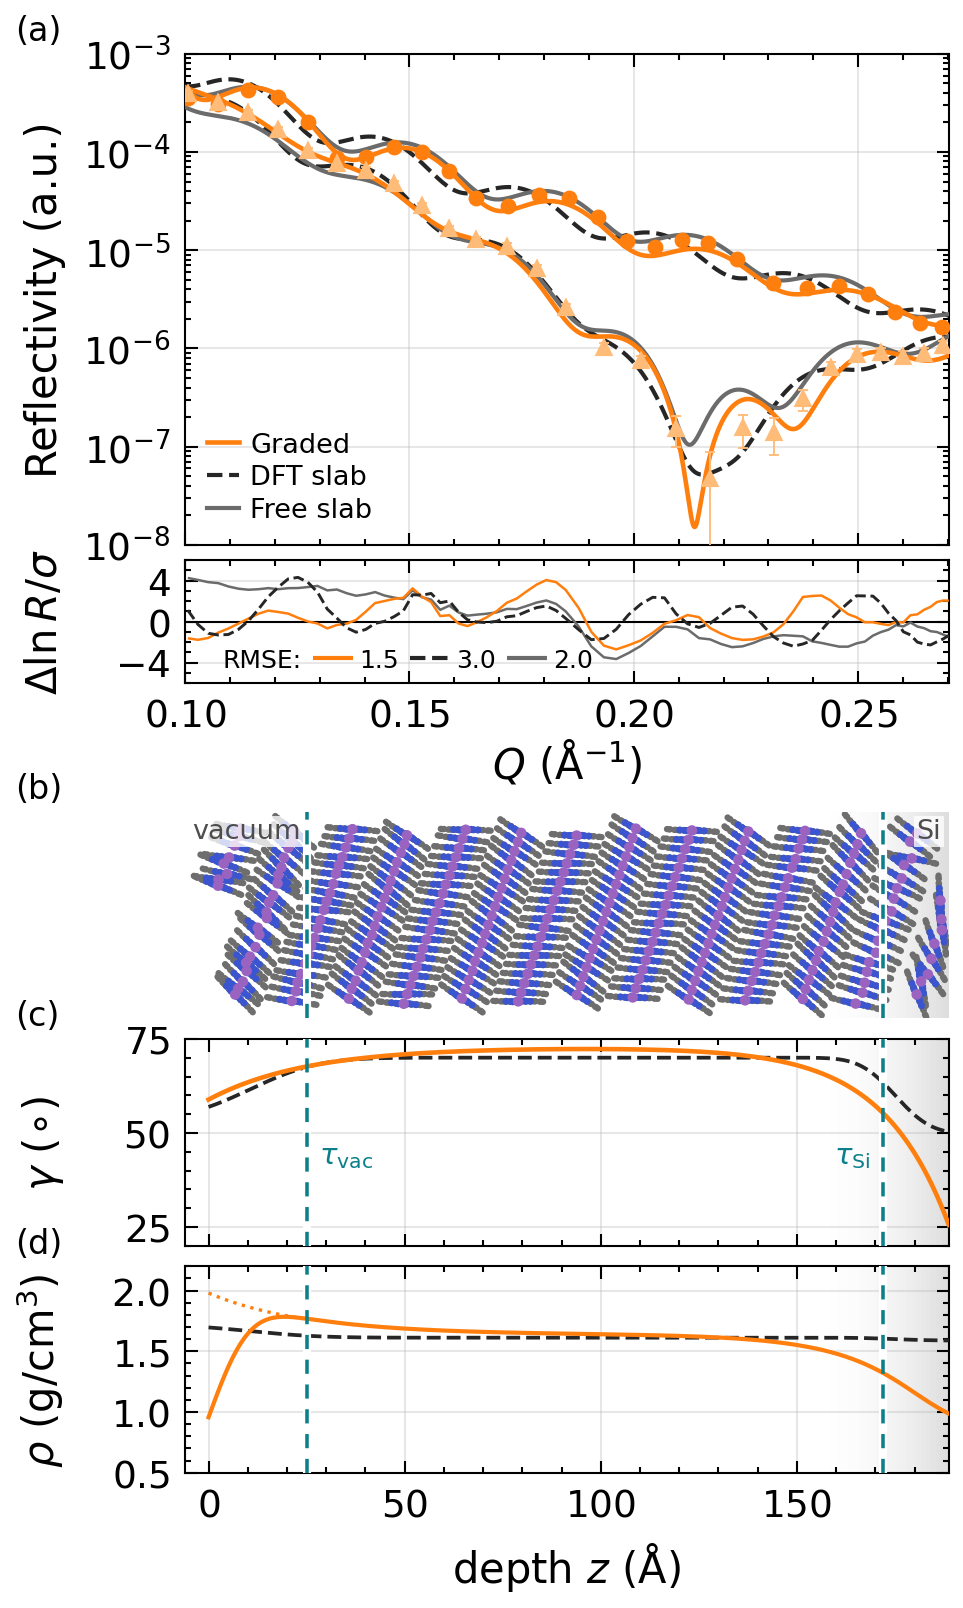

In [56]:
# ============================================================================
# Unrolled FIG4 / fig_5 (PRL single column, 3.35 in), four panels stacked so every
# depth-resolved quantity shares one horizontal depth axis:
#
#   (a) reflectivity + chi_p residual strip           (q axis)
#   (b) herringbone molecule-resolved structure strip (depth axis)
#   (c) gamma(z)                                      (depth axis, shared)
#   (d) rho(z)                                        (depth axis, shared)
#
# Panel (b): ZnPc macrocycles drawn edge-on at true scale. Local tilt magnitude
# comes from gamma(z); within each lamella the molecules alternate herringbone
# sense (+/- reflection across the depth axis) so the strip reads as the
# predicted zig-zag rather than a single parallel stack. Spacing along depth
# still follows rho(z) via site occupancy.
#
# Requires (defined earlier): graded_obj, extract_graded_fit_context,
# nevot_croce_density, draw_reflectivity / draw_residual / draw_orientation /
# draw_density / shade_substrate, and Z_DFT/Z_FREE from the profile cell
# (Z_DFT filled from refloxide_obj via the dft_obj alias).
# ============================================================================
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D

XYZ = Path("tpznpc_0m.xyz")
SHOW_H = False
PLANE_FROM_SURFACE = True
D_LAM = 14.2
PI_STACK = 2.5
L_MOL = 13.6
# Lateral (non-stack / lamella) pitch as a fraction of the macrocycle width.
# Kept separate from PI_STACK so pi-pi and lamella exclusion can be tuned alone.
LAT_FRAC = 1.1
LIBRATION_DEG = 1.5
DISORDER_VAC_DEG = 5.0
DISORDER_SI_DEG = 8.0
POS_DISORDER_VAC = 0.55
POS_DISORDER_SI = 0.85
STRAIN_MIN = 0.90
STRAIN_MAX = 1.35
STRAIN_ANISO_SI = 0.08

# ---- herringbone rendering --------------------------------------------------
# The two translationally inequivalent molecules of the P2_1/n cell have ring
# normals crossed by 86.9 deg (= |180 - 2*theta|, theta = 46.5 deg to the b axis,
# both from tpZnPc_0m.cif). What that pair LOOKS like edge-on depends entirely on
# the viewing azimuth about the surface normal. Projecting both partners for the
# (-101) natural growth facet gives
#
#     view azimuth      partner tilts        splay      crosses horizontal?
#         0 deg        +71.1 / -71.1        142.2            yes
#        60 deg        -47.0 / -75.9         28.9            no
#        70 deg        -60.2 / -75.1         14.8            no
#        90 deg        -71.1 / -71.1          0.0        degenerate
#
# Reflecting the frame (sense = +/-1) is the azimuth-0 case, which is why the
# partners flip across the horizontal and the flow reads as broken. Instead we
# hold a fixed splay taken from a stated viewing azimuth and let the MEAN tilt
# follow gamma(z). Both partners then lean the same way at every depth.
HERRINGBONE_MODE = "splay"      # "splay" (fixed angular width) or "reflect"
HERRINGBONE_SPLAY_DEG = 28.9    # (-101) facet viewed at azimuth 60 deg
TILT_FLOOR_DEG = 5.0            # keep every molecule on one side of the
                                # horizontal: near the substrate gamma falls to
                                # ~26 deg and half the splay plus a disorder
                                # draw can otherwise take it negative, which
                                # reintroduces the flipped look
SEED = 17
SAVENAME = "FIG4"

ELEM_COLORS = {"C": "#6e6e6e", "N": "#3b55d0", "Zn": "#9a63c0"}
ELEM_RADIUS = {"C": 0.60, "N": 0.66, "Zn": 1.00}
BOND_COLOR = "#585858"

# ---- 1. profiles from the optical model -------------------------------------
_film = extract_graded_fit_context(graded_obj).film
Z_G, _RHO_SHARP, RHO_ROUGH = nevot_croce_density(_film)
ALPHA_G = np.degrees(np.asarray(_film.orientation(Z_G), dtype=float))
TOTAL = float(_film.total_thick.value)
TAU_SI = float(_film.tau_si.value)
TAU_VAC = float(_film.tau_vac.value)
TAU_Z = (TAU_VAC, TOTAL - TAU_SI)

Z_DFT = Z_DFT * (TOTAL / float(Z_DFT[-1]))
Z_FREE = Z_FREE * (TOTAL / float(Z_FREE[-1]))


SURF_ROUGH = float(_film.surface_roughness.value)      # Nevot-Croce sigma (A)

# Packing density follows the analytic bookended profile (density_vac ->
# density_bulk -> density_si). Nevot-Croce-smeared RHO_ROUGH erases the
# densified free surface into vacuum and must not drive the lattice.
RHO_MAT = _RHO_SHARP.copy()
RHO_BULK_REF = float(_film.density_bulk.value)


def _gamma(z):
    return float(np.interp(z, Z_G, ALPHA_G))


def _draw_tau(ax, *, halo=False):
    """Interface markers on the structure strip (shared styling from painters)."""
    highlight_interface(ax, halo=halo, labels=False)


# ---- 2. the real molecule ---------------------------------------------------
def _load_znpc():
    """Elements and coordinates with the ring plane in xy, ring normal along +z."""
    lines = XYZ.read_text().splitlines()
    n = int(lines[0].split()[0])
    els = np.array([ln.split()[0] for ln in lines[2:2 + n]])
    xyz = np.array([[float(v) for v in ln.split()[1:4]] for ln in lines[2:2 + n]])
    c = xyz - xyz.mean(0)
    nrm = np.linalg.svd(c)[2][2]
    a = nrm / np.linalg.norm(nrm)
    b = np.array([0.0, 0.0, 1.0])
    v, s = np.cross(a, b), float(np.dot(a, b))
    if np.linalg.norm(v) < 1e-8:
        R = np.eye(3) if s > 0 else -np.eye(3)
    else:
        vx = np.array([[0, -v[2], v[1]], [v[2], 0, -v[0]], [-v[1], v[0], 0]], float)
        R = np.eye(3) + vx + vx @ vx * (1.0 / (1.0 + s))
    return els, c @ R.T


ELS, MOL = _load_znpc()
_dm = np.linalg.norm(MOL[:, None, :] - MOL[None, :, :], axis=-1)
BONDS = [(i, j) for i in range(len(MOL)) for j in range(i + 1, len(MOL))
         if _dm[i, j] < (2.2 if "Zn" in (ELS[i], ELS[j]) else 1.75)
         and (SHOW_H or ("H" not in (ELS[i], ELS[j])))]
KEEP = np.array([SHOW_H or e != "H" for e in ELS])


# ---- 3. panel (b): herringbone structure strip ------------------------------
def _molecule_2d(gamma_deg, centre, sense=1):
    """Edge-on projection of one macrocycle, in (depth, lateral) angstrom.

    In "splay" mode the herringbone partner is selected by offsetting the tilt by
    +/- HERRINGBONE_SPLAY_DEG/2 before this is called, and no reflection is
    applied, so both partners lean the same way. In "reflect" mode the molecular
    frame is mirrored across the depth axis, which is the azimuth-0 projection
    and sends the partners to +/-gamma.
    """
    g = np.radians(gamma_deg)
    s = 1.0 if (sense >= 0 or HERRINGBONE_MODE != "reflect") else -1.0
    n_hat = np.array([np.cos(g), s * np.sin(g)])
    t_hat = np.array([-s * np.sin(g), np.cos(g)])
    mol = MOL
    xy = np.outer(mol[:, 0], t_hat) + np.outer(mol[:, 2], n_hat)
    return xy + centre


def _lattice_scale(z):
    """Areal lattice scale at depth z from the sharp bookended density.

    Returns s such that both stack and lateral pitches stretch as s, with
    s = sqrt(rho_bulk / rho) inside the elastic window. Uses density_vac /
    density_si from the analytic profile, not Nevot-Croce-smeared RHO_ROUGH.
    """
    r = max(float(np.interp(z, Z_G, RHO_MAT)) / RHO_BULK_REF, 1e-3)
    s_ideal = float(np.sqrt(1.0 / r))
    return float(np.clip(s_ideal, STRAIN_MIN, STRAIN_MAX))


def _lattice_state(z):
    """Return (areal scale, residual occupancy) at depth z."""
    r = max(float(np.interp(z, Z_G, RHO_MAT)) / RHO_BULK_REF, 1e-3)
    s_ideal = float(np.sqrt(1.0 / r))
    s = float(np.clip(s_ideal, STRAIN_MIN, STRAIN_MAX))
    return s, float(np.clip((s / max(s_ideal, 1e-6)) ** 2, 0.0, 1.0))


def _occupancy(z):
    """Residual occupancy after elastic clamping."""
    return _lattice_state(z)[1]


def _stack_depths():
    """Uniformly spaced lamellae at the crystallographic repeat."""
    return np.arange(0.5 * D_LAM, TOTAL, D_LAM)


def draw_structure(ax, y_half):
    """Draw a true-scale herringbone strip cropped from an infinite lateral lattice.

    Stacking advances along the local film orientation gamma(z) with a density-
    scaled pi-stack pitch. Columns are indexed forever along the in-plane
    (non-stack) direction; this panel only crops to ``+/- y_half``. Both lattice
    vectors share the areal scale from ``_lattice_scale``.
    ``LAT_FRAC`` sets lamella exclusion independent of the pi-pi pitch.
    Mean molecular tilt follows gamma(z) with interface disorder; ``TILT_FLOOR``
    keeps the herringbone on one side of the film.
    """
    rng = np.random.default_rng(SEED)
    segs, pts, elem = [], [], []
    r_keep = 0.28 * L_MOL

    _kk = np.array([1.0, 1.7, 2.6, 3.9, 5.3, 7.1])
    _ph = rng.uniform(0, 2 * np.pi, _kk.size)

    def z_surface(y):
        s_ = np.sin(2 * np.pi * _kk * (y + y_half) / (2 * y_half) + _ph).sum()
        return 0.35 * SURF_ROUGH * s_ / np.sqrt(_kk.size / 2.0)

    # Lateral (non-stack) frame from bulk orientation; columns tile forever
    # along t_hat and the axes crop to the panel.
    g_bulk = np.radians(float(np.median(ALPHA_G)))
    t_hat = np.array([-np.sin(g_bulk), np.cos(g_bulk)])
    n_bulk = np.array([np.cos(g_bulk), np.sin(g_bulk)])
    if abs(n_bulk[0]) < 0.25:
        n_bulk = np.array([0.25, np.sqrt(max(0.0, 1.0 - 0.25**2))])
        n_bulk /= np.linalg.norm(n_bulk)
        t_hat = np.array([-n_bulk[1], n_bulk[0]])

    s_lat = _lattice_scale(float(Z_G[int(np.argmax(RHO_MAT))]))
    lat_ref = L_MOL * LAT_FRAC * s_lat
    drift = abs(n_bulk[1] / max(n_bulk[0], 0.25)) * (TOTAL - Z_LEFT)
    n_j = int(np.ceil((y_half + L_MOL + drift) / lat_ref)) + 6

    for j in range(-n_j, n_j + 1):
        offset = j * lat_ref * t_hat
        s0 = (Z_LEFT - float(offset[0])) / float(n_bulk[0])
        pos = offset + s0 * n_bulk
        sense = 1 if (j % 2 == 0) else -1
        for _ in range(1200):
            z = float(pos[0])
            y = float(pos[1])
            if z > TOTAL + 0.5 * L_MOL:
                break
            if (
                Z_LEFT + r_keep <= z <= TOTAL
                and abs(y) <= y_half - r_keep
                and z >= max(z_surface(y), 0.5)
            ):
                z_clip = float(np.clip(z, 0.0, TOTAL))
                amorph_si = float(np.exp(-(TOTAL - z_clip) / TAU_SI))
                amorph_vac = float(np.exp(-z_clip / TAU_VAC))
                spread = (
                    LIBRATION_DEG
                    + DISORDER_VAC_DEG * amorph_vac
                    + DISORDER_SI_DEG * amorph_si
                )
                jit = POS_DISORDER_VAC * amorph_vac + POS_DISORDER_SI * amorph_si
                centre = pos + rng.normal(0.0, jit, 2)
                g = _gamma(z_clip) + rng.normal(0.0, spread)
                if HERRINGBONE_MODE == "splay":
                    g += 0.5 * HERRINGBONE_SPLAY_DEG * (1 if sense >= 0 else -1)
                    g = max(g, TILT_FLOOR_DEG)
                xy = _molecule_2d(g, centre, sense=sense)
                segs += [[xy[a], xy[b]] for a, b in BONDS]
                pts.append(xy[KEEP])
                elem.append(ELS[KEEP])

            # Density scales the pitch; orientation enters through the bulk
            # stack frame (columns) and local gamma at draw time (molecules).
            z_clip = float(np.clip(z, 0.0, TOTAL))
            scale = _lattice_scale(z_clip)
            amorph_si = float(np.exp(-(TOTAL - z_clip) / TAU_SI))
            aniso = 1.0 + STRAIN_ANISO_SI * amorph_si
            pos = pos + (PI_STACK * scale * aniso) * n_bulk

    if not pts:
        raise RuntimeError("draw_structure produced no molecules")
    pts = np.vstack(pts)
    elem = np.concatenate(elem)

    ax.add_collection(LineCollection(segs, colors=BOND_COLOR, linewidths=0.45,
                                     zorder=3, capstyle="round"))
    for e, col in ELEM_COLORS.items():
        m = elem == e
        if m.any():
            ax.scatter(pts[m, 0], pts[m, 1], s=(2 * ELEM_RADIUS[e]) ** 2 * 1.6,
                       c=col, edgecolors="none", zorder=4)
    _draw_tau(ax, halo=True)
    _lab_bbox = dict(fc="white", ec="none", alpha=0.78, pad=0.6)
    ax.annotate("vacuum", xy=(0.010, 0.97), xycoords="axes fraction",
                fontsize=6.5, color="0.3", ha="left", va="top", bbox=_lab_bbox,
                zorder=10)
    ax.annotate("Si", xy=(0.990, 0.97), xycoords="axes fraction",
                fontsize=6.5, color="0.3", ha="right", va="top", bbox=_lab_bbox,
                zorder=10)
    ax.set_yticks([])
    ax.tick_params(which="both", left=False, right=False, bottom=False,
                   top=False, labelleft=False, labelright=False,
                   labelbottom=False, labeltop=False, length=0)
    for _t in list(ax.xaxis.get_major_ticks()) + list(ax.xaxis.get_minor_ticks()):
        _t.tick1line.set_visible(False); _t.tick2line.set_visible(False)
        _t.label1.set_visible(False); _t.label2.set_visible(False)
    ax.grid(False)
    for sp in ("left", "right", "top", "bottom"):
        ax.spines[sp].set_visible(False)


# ---- 4. assemble ------------------------------------------------------------
fig = plt.figure(figsize=(3.35, 5.5), dpi=300)
outer = fig.add_gridspec(2, 1, height_ratios=[1.60, 1.68], hspace=0.2,
                         left=0.205, right=0.965, top=0.955, bottom=0.095)
top = outer[0].subgridspec(2, 1, height_ratios=[4, 1.0], hspace=0.05)
bot = outer[1].subgridspec(3, 1, height_ratios=[1.0, 1.0, 1.0], hspace=0.1)
axR = fig.add_subplot(top[0])
axres = fig.add_subplot(top[1], sharex=axR)
axS = fig.add_subplot(bot[0])
axa = fig.add_subplot(bot[1], sharex=axS)
axd = fig.add_subplot(bot[2], sharex=axS)

draw_reflectivity(axR)
axR.tick_params(labelbottom=False)
draw_residual(axres)
axres.xaxis.labelpad = 1

draw_orientation(axa)
axa.tick_params(bottom=True, labelbottom=False)
shade_substrate(axa)

draw_density(axd)
shade_substrate(axd)
axd.tick_params(bottom=True, labelbottom=True)
axd.set_xlabel(r"depth $z\ (\mathrm{\AA})$")

fig.canvas.draw()
_pos = axS.get_position()
_w_in = _pos.width * fig.get_size_inches()[0]
_h_in = _pos.height * fig.get_size_inches()[1]
_xspan = DEPTH_XLIM[1] - DEPTH_XLIM[0]
_y_half = 0.5 * _xspan * (_h_in / _w_in)
draw_structure(axS, _y_half)
shade_substrate(axS)
axS.set_xlim(*DEPTH_XLIM)
axS.set_ylim(-_y_half, _y_half)
axS.tick_params(which="both", left=False, right=False, bottom=False, top=False,
                labelleft=False, labelright=False, labelbottom=False,
                labeltop=False, length=0)
for _t in list(axS.xaxis.get_major_ticks()) + list(axS.xaxis.get_minor_ticks()):
    _t.tick1line.set_visible(False); _t.tick2line.set_visible(False)
    _t.label1.set_visible(False); _t.label2.set_visible(False)
for _ax in (axa, axd):
    _ax.set_xlim(*DEPTH_XLIM)

fig.align_ylabels()
fig.canvas.draw()
_rend = fig.canvas.get_renderer()
_xlab = min(
    fig.transFigure.inverted().transform(
        (_ax.yaxis.label.get_window_extent(renderer=_rend).x0, 0)
    )[0]
    for _ax in (axR, axa, axd)
)
for _ax, _lab in ((axR, "(a)"), (axS, "(b)"), (axa, "(c)"), (axd, "(d)")):
    fig.text(_xlab, _ax.get_position().y1 + 0.004, _lab,
             fontsize=8, va="bottom", ha="left")
fig.align_ylabels()

fig.savefig(f"{SAVENAME}.pdf", dpi=600, transparent=True)
fig.savefig(f"{SAVENAME}.png", dpi=600, transparent=True)
plt.show()
